# Fase 4 — Detecção de Anomalias: Candidatos 2026 (TSE)

## Pergunta de negócio

> **Existem candidatos com um perfil claramente atípico — seja em relação a toda a base, seja em relação ao grupo (cluster) a que pertencem?**

Isso é, na verdade, **duas perguntas diferentes**:

1. **Anomalia global** — esse candidato foge do padrão de todos os ~2800 candidatos a desputado federal no sudeste, não importa o cluster?
2. **Anomalia local (dentro do cluster)** — esse candidato foge do padrão do **seu próprio grupo**? Um candidato pode ser perfeitamente comum na base inteira e ainda assim se destacar dentro do cluster **Jovens** (ex.: o mais velho do grupo) — ou o contrário: parecer estranho olhando a base toda, mas ser exatamente o que se espera dentro do seu cluster.

Usamos os clusters nomeados na Fase 2 (`02_clusterizacao.ipynb`, Bisecting K-Means, k=4: **Elite Financeira**, **Acadêmicos de Baixo Orçamento**, **Financiados Sem Patrimônio** e **Perfil Tradicional**  ) e o algoritmo **Isolation Forest** — diferente de tudo que vimos até aqui: K-Means/Bisecting/hierárquico procuram *grupos*; DBSCAN também procura densidade; o Isolation Forest procura diretamente **quem é fácil de isolar do resto**.


## Configuração

Use os **mesmos valores** que você usou nas Fases 0/1/2/3.


In [1]:
from google.colab import drive
drive.mount('/content/drive');

Mounted at /content/drive


In [2]:
CARGO = "DEPUTADO FEDERAL"
UF = ["SP", "RJ", "MG", "ES"]               # mesmo valor usado na Fase 0/1, 0/1/2
ANO_ELEICAO = 2026


## Preparando a base — reconstituindo os clusters nomeados da Fase 2

Mesma lógica de auto-suficiência já usada em `02_clusterizacao_outros.ipynb` e `03_regras_associacao.ipynb`: recalculamos aqui, rapidamente, o **Bisecting K-Means (k=3)** da Fase 2 e aplicamos os mesmos nomes — pra este notebook rodar sozinho, sem depender de nenhum arquivo intermediário salvo pelos outros.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules

!pip install pyvis # Install pyvis library
from pyvis.network import Network
from IPython.display import IFrame

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)  # não truncar antecedents/consequents nas tabelas

SEMENTE = 42
np.random.seed(SEMENTE)  # mesmo racional de reprodutibilidade defensiva dos notebooks anteriores

nome_cargo = CARGO.replace(' ', '_')

# Formatação corrigida para corresponder ao nome real do ficheiro
if UF is not None:
    if isinstance(UF, list):
        # Gera o formato ('SP', 'RJ', 'MG', 'ES')
        nome_uf_formatted = str(tuple(UF))
    else:
        nome_uf_formatted = UF
else:
    nome_uf_formatted = 'BRASIL'

arquivo = f"/content/drive/MyDrive/dados/candidatos_{nome_cargo}_{nome_uf_formatted}_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/756.0 kB 944.0 kB/s eta 0:00:01

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━ 522.2/756.0 kB 1.4 MB/s eta 0:00:01

...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Carregado: /content/drive/MyDrive/dados/candidatos_DEPUTADO_FEDERAL_('SP', 'RJ', 'MG', 'ES')_2026.csv  ->  2800 candidatos, 59 colunas


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531643,3090,JOÃO BATISTA DE ASSIS,SARGENTO ASSIS,#NULO,3152826737,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1974-03-23,14740511465,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),2,PRETA,278,VEREADOR,-1,#NULO,400000.0,92500.0,0.0,0.0,0.0,0.0,492500.0,13.107252,52
1,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531644,3010,FABÍOLA SAQUETTO DI TOMMASO,FABÍOLA SAQUETTO,#NULO,7106495760,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1977-08-06,17880711481,4,FEMININO,8,SUPERIOR COMPLETO,5,VIÚVO(A),1,BRANCA,257,EMPRESÁRIO,-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,49
2,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531645,3060,AILANA REGINA PELISSARI SIMONELLI MOREIRA,AILANA PELISSARI,#NULO,9365295718,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1978-11-28,19854371449,4,FEMININO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),3,PARDA,999,OUTROS,-1,#NULO,0.0,0.0,0.0,0.0,0.0,60000.0,60000.0,11.002117,47
3,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531646,3040,JÚLIO CÉSAR COSTA CAIADO,DR. JÚLIO CAIADO,#NULO,33301018653,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1959-04-17,11524561414,2,MASCULINO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,112,VETERINÁRIO,-1,#NULO,900000.0,115000.0,0.0,0.0,0.0,0.0,1015000.0,13.830400,67
4,27/08/2026,12:30:35,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,ES,ES,ESPÍRITO SANTO,6,DEPUTADO FEDERAL,80002531647,3033,LEONARDO RODRIGO NASCIMENTO,LÉO SINDICO,#NULO,7877752741,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,80001800054,PARTIDO ISOLADO,NOVO,ES,1979-11-14,19497891406,2,MASCULINO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),3,PARDA,257,EMPRESÁRIO,-1,#NULO,300000.0,52000.0,0.0,0.0,0.0,0.0,352000.0,12.771389,46


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [4]:
# 1. Carregar o dataset de despesas ajustando o encoding e separador
caminho_despesas = "/content/drive/MyDrive/dados/despesas_contratadas_candidatos_2026_BRASIL.csv"
df_dc_final = pd.read_csv(caminho_despesas, encoding='latin1', sep=';')

# 2. Garantir que as chaves de junção (SQ_CANDIDATO) estão no mesmo formato (string)
df['SQ_CANDIDATO'] = df['SQ_CANDIDATO'].astype(str).str.strip()
df_dc_final['SQ_CANDIDATO'] = df_dc_final['SQ_CANDIDATO'].astype(str).str.strip()

# 3. Converter a coluna de valores para float
if df_dc_final['VR_DESPESA_CONTRATADA'].dtype == 'object':
    df_dc_final['VR_DESPESA_CONTRATADA'] = (
        df_dc_final['VR_DESPESA_CONTRATADA']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
df_dc_final['VR_DESPESA_CONTRATADA'] = pd.to_numeric(df_dc_final['VR_DESPESA_CONTRATADA'], errors='coerce').fillna(0)

# 4. Agrupar por SQ_CANDIDATO e calcular o total
df_despesas_totais = (
    df_dc_final.groupby('SQ_CANDIDATO')['VR_DESPESA_CONTRATADA']
    .sum()
    .reset_index()
    .rename(columns={'VR_DESPESA_CONTRATADA': 'Total_Despesas'})
)

# 5. Remover a coluna se já existia de execuções anteriores para evitar duplicados (ex: Total_Despesas_x)
if 'Total_Despesas' in df.columns:
    df.drop(columns=['Total_Despesas'], inplace=True)

# 6. Fazer a junção (merge)
df = df.merge(df_despesas_totais, on='SQ_CANDIDATO', how='left')

# 7. Tratar nulos e calcular a transformação logarítmica
df['Total_Despesas'] = df['Total_Despesas'].fillna(0)
df['Total_Despesas_Log'] = np.log1p(df['Total_Despesas'])

print("Variável Total_Despesas adicionada com sucesso!\n")
print(df[['SQ_CANDIDATO', 'Total_Despesas', 'Total_Despesas_Log']].head())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Variável Total_Despesas adicionada com sucesso!

  SQ_CANDIDATO  Total_Despesas  Total_Despesas_Log
0  80002531643            0.00            0.000000
1  80002531644         3750.00            8.229778
2  80002531645         5000.00            8.517393
3  80002531646            9.95            2.393339
4  80002531647         5275.19            8.570960


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [5]:
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
    # 'NÃO DIVULGÁVEL' fica de fora de propósito — mesma decisão da Versão 2 do notebook de clusterização
}

df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].map(ANOS_ESTUDO_POR_GRAU)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [6]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log','Total_Despesas_Log']

Q1, Q3 = df['Total_Bens_Log'].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_cluster = df[(df['Total_Bens_Log'] <= limite_superior) & (df['ANOS_ESTUDO'].notna())].copy()
df_cluster = df_cluster.reset_index(drop=True)
print(f"Base: {df_cluster.shape[0]} candidatos "
      f"(descartados {df.shape[0] - df_cluster.shape[0]} por patrimônio extremo ou escolaridade não divulgada)")

scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])

Base: 2800 candidatos (descartados 0 por patrimônio extremo ou escolaridade não divulgada)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [7]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log','Total_Despesas_Log']

Q1, Q3 = df['Total_Despesas_Log'].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_cluster = df[(df['Total_Despesas_Log'] <= limite_superior) & (df['ANOS_ESTUDO'].notna())].copy()
df_cluster = df_cluster.reset_index(drop=True)
print(f"Base: {df_cluster.shape[0]} candidatos "
      f"(descartados {df.shape[0] - df_cluster.shape[0]} por despesa extremo ou escolaridade não divulgada)")

scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])


Base: 2800 candidatos (descartados 0 por despesa extremo ou escolaridade não divulgada)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [10]:
def inercia(indices):
    if len(indices) < 2:
        return 0.0
    pontos = X[indices]
    centro = pontos.mean(axis=0)
    return float(((pontos - centro) ** 2).sum(axis=1).mean())


def bisecting_kmeans_ate_k(X, k_max, random_state=SEMENTE):
    """Mesma lógica do 02_clusterizacao.ipynb (Parte 2, critério de inércia média) — só a
    partição final em k_max clusters, sem guardar o histórico de divisões."""
    clusters = {0: np.arange(X.shape[0])}
    proximo_id = 1
    for _ in range(1, k_max):
        id_escolhido = max(clusters, key=lambda cid: len(clusters[cid]))
        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break
        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2
        del clusters[id_escolhido]
        clusters[id_a] = indices_pai[labels2 == 0]
        clusters[id_b] = indices_pai[labels2 == 1]
    return clusters


k_bisecting = 4  # mesmo k escolhido no 02_clusterizacao.ipynb (Parte 2)

clusters_finais = bisecting_kmeans_ate_k(X, k_bisecting)
ids_por_tamanho = sorted(clusters_finais, key=lambda cid: len(clusters_finais[cid]), reverse=True)

rotulos = np.empty(X.shape[0], dtype=object)
for letra, cid in zip([chr(65 + i) for i in range(len(ids_por_tamanho))], ids_por_tamanho):
    rotulos[clusters_finais[cid]] = letra
df_cluster['cluster_bisecting'] = rotulos

# mesmos nomes definidos no 02_clusterizacao.ipynb, a partir da mesma ficha técnica
NOMES_CLUSTER_BISECTING = {
    'A': 'Elite Financeira e Eleitoral',
    'B': 'Acadêmicos de Baixo Orçamento',
    'C': 'Financiados sem Patrimônio',
    'D': 'Perfil Tradicional'
}
df_cluster['cluster'] = df_cluster['cluster_bisecting'].map(NOMES_CLUSTER_BISECTING)

df_cluster['cluster'].value_counts()


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,count
cluster,
Elite Financeira e Eleitoral,1127
Acadêmicos de Baixo Orçamento,795
Financiados sem Patrimônio,515
Perfil Tradicional,363


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

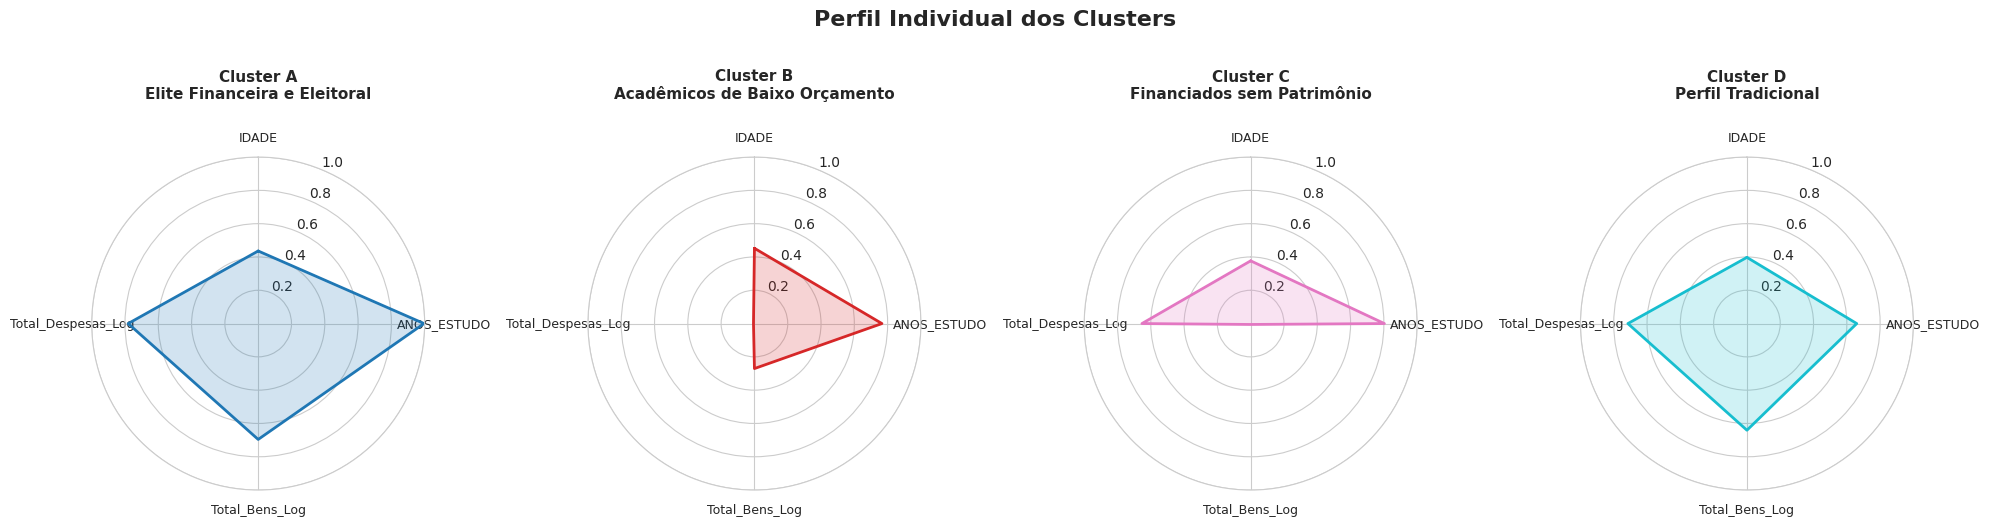

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

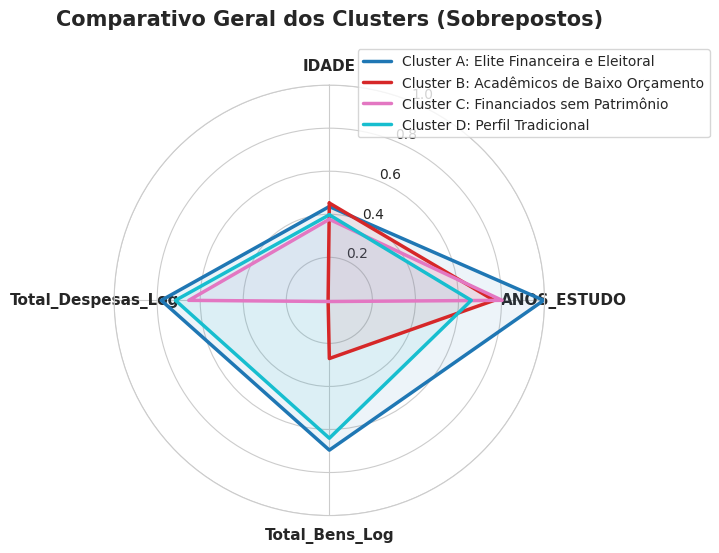

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [12]:
from math import pi
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURAÇÕES GERAIS ---
k_bisecting = 4
letras_ordenadas = [chr(65 + i) for i in range(k_bisecting)]  # Gera ['A', 'B', 'C', 'D', 'E']

cols_radar = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Log']

cores_radar = {
    'A': '#1f77b4',  # Azul
    'B': '#d62728',  # Vermelho
    'C': '#e377c2',  # Rosa
    'D': '#17becf',  # Ciano
}

# --- 2. CÁLCULO E NORMALIZAÇÃO DOS CENTROIDES ---
df_radar = df_cluster[cols_radar].copy()
df_radar = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())
df_radar['cluster_letra'] = df_cluster['cluster_bisecting']

centroides_df = df_radar.groupby('cluster_letra')[cols_radar].mean().loc[letras_ordenadas]

# Preparação dos ângulos
n_eixos = len(cols_radar)
angulos = [n / float(n_eixos) * 2 * pi for n in range(n_eixos)]
angulos += angulos[:1]  # Fechar o polígono


# ==============================================================================
# PARTE 1: GRÁFICOS SEPARADOS (UM RADAR POR CLUSTER)
# ==============================================================================
ncols = 3 if k_bisecting > 4 else 4
nrows = -(-k_bisecting // ncols)

fig_sep, axes_sep = plt.subplots(
    nrows, ncols, figsize=(5 * ncols, 5 * nrows), subplot_kw=dict(polar=True)
)
axes_sep = np.array(axes_sep).flatten() if k_bisecting > 1 else [axes_sep]

for i, letra in enumerate(letras_ordenadas):
    ax = axes_sep[i]
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(cols_radar, fontsize=9)
    ax.set_ylim(0, 1)

    valores = centroides_df.loc[letra, cols_radar].values.tolist()
    valores += valores[:1]

    cor = cores_radar.get(letra, '#333333')
    ax.plot(angulos, valores, linewidth=2, color=cor)
    ax.fill(angulos, valores, alpha=0.2, color=cor)

    nome_descritivo = NOMES_CLUSTER_BISECTING.get(letra, "")
    ax.set_title(
        f"Cluster {letra}\n{nome_descritivo}",
        y=1.15,
        fontsize=11,
        fontweight="bold"
    )

# Deleta eixos extras da grade se houver
for j in range(len(letras_ordenadas), len(axes_sep)):
    fig_sep.delaxes(axes_sep[j])

fig_sep.suptitle("Perfil Individual dos Clusters", fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


# ==============================================================================
# PARTE 2: GRÁFICO COMPARATIVO (TODOS OS CLUSTERS JUNTOS)
# ==============================================================================
fig_junto, ax_junto = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax_junto.set_theta_offset(pi / 2)
ax_junto.set_theta_direction(-1)
ax_junto.set_xticks(angulos[:-1])
ax_junto.set_xticklabels(cols_radar, fontsize=11, fontweight='bold')
ax_junto.set_ylim(0, 1)

for letra in letras_ordenadas:
    valores = centroides_df.loc[letra, cols_radar].values.tolist()
    valores += valores[:1]

    cor = cores_radar.get(letra, '#333333')
    label_txt = f"Cluster {letra}: {NOMES_CLUSTER_BISECTING.get(letra, '')}"

    ax_junto.plot(angulos, valores, linewidth=2.5, label=label_txt, color=cor)
    ax_junto.fill(angulos, valores, alpha=0.08, color=cor)

plt.title("Comparativo Geral dos Clusters (Sobrepostos)", y=1.12, fontsize=15, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

## Isolation Forest: como funciona

Todos os algoritmos das fases anteriores definem "normal" de forma indireta: K-Means olha distância até um centro, DBSCAN olha densidade de vizinhança. O **Isolation Forest** faz a pergunta ao contrário, e de forma bem mais direta: **quão fácil é isolar este ponto do resto, cortando o espaço aleatoriamente?**

A ideia, passo a passo:

1. Constrói várias **árvores de isolamento** (isolation trees). Cada árvore escolhe, em cada nó, uma variável **aleatória** e um ponto de corte **aleatório** entre o mínimo e o máximo daquela variável ali — sem nenhuma lógica de "melhor corte" como numa árvore de decisão comum.
2. Repete o corte recursivamente até que cada ponto fique sozinho numa partição.
3. Pontos **isolados** (poucos e diferentes do resto) tendem a cair sozinhos logo nos primeiros cortes — **caminho curto** da raiz até a folha. Pontos numa região **densa** (muitos vizinhos parecidos) precisam de muito mais cortes até se separarem de todo mundo — **caminho longo**.
4. O **score de anomalia** de cada ponto é a média do comprimento desse caminho em todas as árvores da floresta, normalizada — quanto **menor** o caminho médio, mais anômalo.

Duas vantagens práticas: não precisa calcular distância entre todos os pares de pontos (como DBSCAN/hierárquico), então escala bem; e não assume nenhuma forma pro que é "normal" (nem esférica, como K-Means, nem uma região densa contígua, como DBSCAN).

**O parâmetro `contamination`** é a fração de pontos que vocês **esperam de antemão** que sejam anômalos — é uma suposição de quem está modelando, não algo medido a partir dos dados (mesmo espírito do `k` do K-Means ou do `eps` do DBSCAN: um parâmetro que exige julgamento, não tem uma resposta "correta" automática).

### Vendo com dados fictícios

Como com dado real nunca sabemos de verdade quem é anômalo, geramos aqui uma base fictícia onde **nós** decidimos quem é "normal" (dois grupos bem comportados) e quem é "anômalo" (pontos espalhados aleatoriamente pelo espaço) — aí comparamos com o que o algoritmo encontra sozinho, sem ver esses rótulos.


In [13]:


rng = np.random.default_rng(SEMENTE)

# "normal": dois grupos bem comportados (como se fossem 2 clusters)
normal_1 = rng.normal(loc=[2, 2], scale=0.6, size=(80, 2))
normal_2 = rng.normal(loc=[6, 6], scale=0.6, size=(80, 2))
X_normal_ficticio = np.vstack([normal_1, normal_2])

# "anômalo": pontos espalhados aleatoriamente pelo espaço, longe dos dois grupos
X_anomalo_ficticio = rng.uniform(low=-2, high=10, size=(12, 2))

X_ficticio = np.vstack([X_normal_ficticio, X_anomalo_ficticio])
rotulo_real_ficticio = np.array(['Normal'] * len(X_normal_ficticio) + ['Anômalo (fictício)'] * len(X_anomalo_ficticio))

# contamination = a fração real de anômalos fictícios (aqui podemos "trapacear" porque sabemos)
iso_ficticio = IsolationForest(contamination=len(X_anomalo_ficticio) / len(X_ficticio),
                                random_state=SEMENTE, n_estimators=200)
pred_ficticio = iso_ficticio.fit_predict(X_ficticio)
score_ficticio = iso_ficticio.decision_function(X_ficticio)

print(f"Score médio — Normal: {score_ficticio[rotulo_real_ficticio == 'Normal'].mean():.3f}  |  "
      f"Anômalo: {score_ficticio[rotulo_real_ficticio == 'Anômalo (fictício)'].mean():.3f}")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Score médio — Normal: 0.132  |  Anômalo: -0.092


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

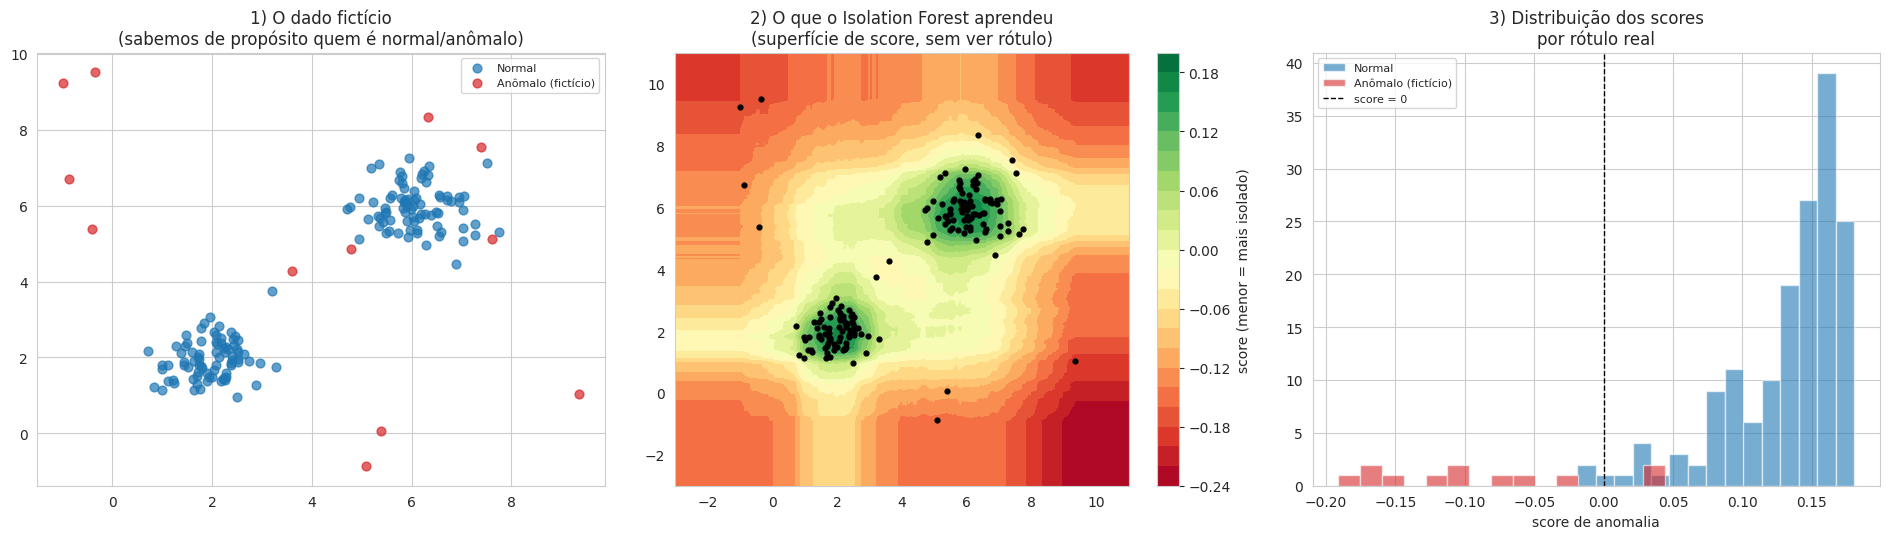

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

cores_ficticio = {'Normal': 'tab:blue', 'Anômalo (fictício)': 'tab:red'}
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    axes[0].scatter(X_ficticio[m, 0], X_ficticio[m, 1], c=cor, label=rotulo, alpha=0.7, s=40)
axes[0].set_title('1) O dado fictício\n(sabemos de propósito quem é normal/anômalo)')
axes[0].legend(fontsize=8)

# superfície de score: o que o algoritmo "enxerga", sem ver rótulo nenhum
xx, yy = np.meshgrid(np.linspace(-3, 11, 300), np.linspace(-3, 11, 300))
Z = iso_ficticio.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
cs = axes[1].contourf(xx, yy, Z, levels=20, cmap='RdYlGn')
axes[1].scatter(X_ficticio[:, 0], X_ficticio[:, 1], c='black', s=12)
plt.colorbar(cs, ax=axes[1], label='score (menor = mais isolado)')
axes[1].set_title('2) O que o Isolation Forest aprendeu\n(superfície de score, sem ver rótulo)')

# distribuição dos scores por rótulo real
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    axes[2].hist(score_ficticio[m], bins=15, color=cor, alpha=0.6, label=rotulo)
axes[2].axvline(0, color='black', linestyle='--', linewidth=1, label='score = 0')
axes[2].set_title('3) Distribuição dos scores\npor rótulo real')
axes[2].set_xlabel('score de anomalia')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


A superfície de score (painel 2) fica **verde** (score alto, "normal") bem em cima dos dois grupos densos, e **vermelha** (score baixo, "anômalo") nas bordas e longe de tudo — exatamente onde estão os pontos fictícios que geramos como "anômalos". O algoritmo nunca viu o rótulo `Normal`/`Anômalo (fictício)`: ele chegou nisso só de contar quão rápido cada ponto fica isolado. O histograma (painel 3) mostra a mesma coisa de outro ângulo: os scores dos pontos normais ficam concentrados bem acima de zero; os anômalos, misturados mais pra baixo — a separação não é perfeita (alguns anômalos fictícios caíram por sorte perto dos grupos densos), o que já é um bom aviso pra quando aplicarmos em dado real: o Isolation Forest não é infalível, é uma sugestão de onde olhar com mais atenção.


### Por dentro de uma única árvore

A superfície de score acima é o resultado **já combinado** de 200 árvores. Pra enxergar o mecanismo de verdade — os cortes aleatórios que dão nome ao algoritmo — olhamos uma árvore sozinha: cada linha abaixo é um corte (variável aleatória, ponto de corte aleatório entre o mínimo e o máximo ali). Escolhemos dois pontos de propósito — um bem no meio de um grupo denso, outro o mais "anômalo" segundo o próprio modelo — e comparamos quantos cortes cada um precisou até ficar sozinho numa partição.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

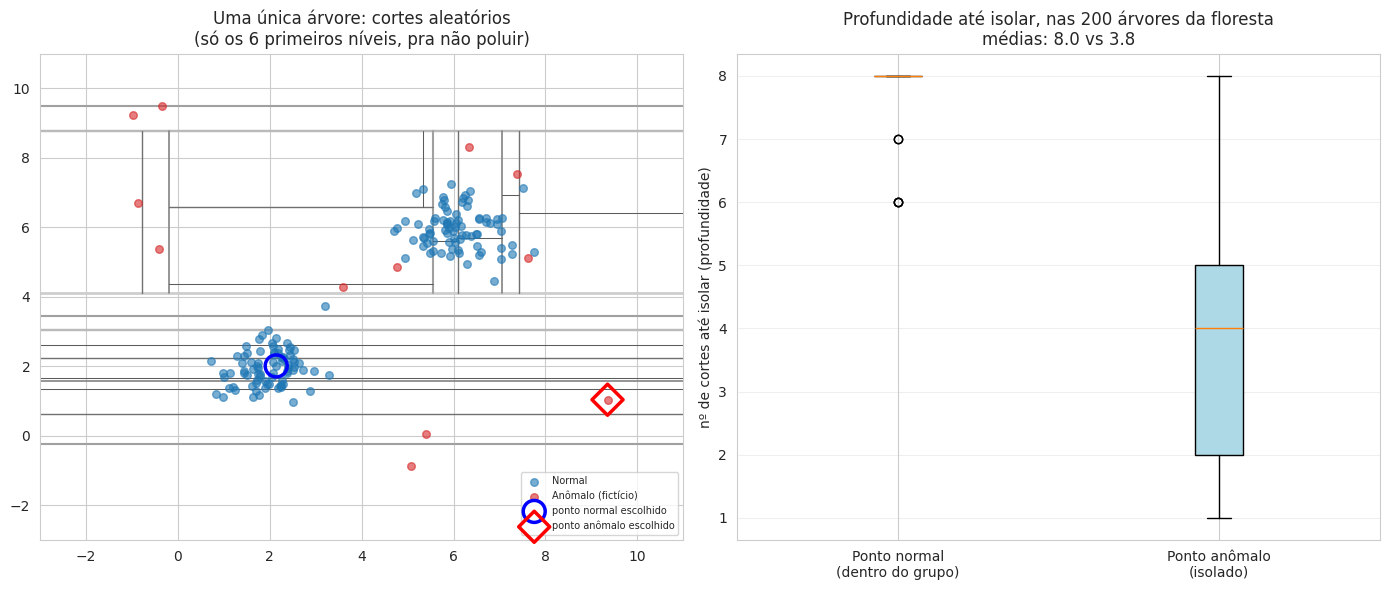

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [15]:
def desenhar_particoes(ax, tree_, no, x_min, x_max, y_min, y_max, profundidade=0, profundidade_max=6):
    """Desenha recursivamente os cortes de uma árvore de isolamento dentro de uma caixa
    [x_min,x_max] x [y_min,y_max]. Só os primeiros `profundidade_max` níveis são desenhados —
    a árvore de verdade continua até isolar cada ponto sozinho, mas isso poluiria demais o
    desenho sem ajudar a entender a ideia."""
    if profundidade >= profundidade_max or tree_.children_left[no] == -1:  # -1 = folha
        return
    variavel, limiar = tree_.feature[no], tree_.threshold[no]
    cor = plt.cm.Greys(0.3 + 0.5 * profundidade / profundidade_max)
    espessura = max(2 - 0.25 * profundidade, 0.4)
    if variavel == 0:
        ax.plot([limiar, limiar], [y_min, y_max], color=cor, linewidth=espessura)
        desenhar_particoes(ax, tree_, tree_.children_left[no], x_min, limiar, y_min, y_max, profundidade + 1, profundidade_max)
        desenhar_particoes(ax, tree_, tree_.children_right[no], limiar, x_max, y_min, y_max, profundidade + 1, profundidade_max)
    else:
        ax.plot([x_min, x_max], [limiar, limiar], color=cor, linewidth=espessura)
        desenhar_particoes(ax, tree_, tree_.children_left[no], x_min, x_max, y_min, limiar, profundidade + 1, profundidade_max)
        desenhar_particoes(ax, tree_, tree_.children_right[no], x_min, x_max, limiar, y_max, profundidade + 1, profundidade_max)


def profundidade_isolamento(tree_, ponto):
    """Quantos cortes uma árvore precisa até isolar `ponto` sozinho numa folha."""
    no, profundidade = 0, 0
    while tree_.children_left[no] != -1:
        variavel, limiar = tree_.feature[no], tree_.threshold[no]
        no = tree_.children_left[no] if ponto[variavel] <= limiar else tree_.children_right[no]
        profundidade += 1
    return profundidade


# dois pontos escolhidos de propósito: o mais "normal" (mais perto do centro do 1º grupo) e o
# mais "anômalo" de verdade segundo o próprio modelo (menor score entre os pontos fictícios)
ponto_normal = X_normal_ficticio[np.argmin(np.linalg.norm(X_normal_ficticio - [2, 2], axis=1))]
scores_dos_anomalos = iso_ficticio.decision_function(X_anomalo_ficticio)
ponto_anomalo = X_anomalo_ficticio[np.argmin(scores_dos_anomalos)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# painel A: uma única árvore da floresta, cortes desenhados
ax = axes[0]
x_min, x_max, y_min, y_max = -3, 11, -3, 11
uma_arvore = iso_ficticio.estimators_[0].tree_
desenhar_particoes(ax, uma_arvore, 0, x_min, x_max, y_min, y_max)
for rotulo, cor in cores_ficticio.items():
    m = rotulo_real_ficticio == rotulo
    ax.scatter(X_ficticio[m, 0], X_ficticio[m, 1], c=cor, alpha=0.6, s=30, label=rotulo, zorder=3)
ax.scatter(*ponto_normal, s=250, facecolor='none', edgecolor='blue', linewidth=2.5, zorder=4, label='ponto normal escolhido')
ax.scatter(*ponto_anomalo, s=250, facecolor='none', edgecolor='red', linewidth=2.5, marker='D', zorder=4, label='ponto anômalo escolhido')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title('Uma única árvore: cortes aleatórios\n(só os 6 primeiros níveis, pra não poluir)')
ax.legend(fontsize=7, loc='lower right')

# painel B: profundidade até isolar cada um dos 2 pontos, em TODAS as árvores da floresta
profundidades_normal = [profundidade_isolamento(arv.tree_, ponto_normal) for arv in iso_ficticio.estimators_]
profundidades_anomalo = [profundidade_isolamento(arv.tree_, ponto_anomalo) for arv in iso_ficticio.estimators_]

ax2 = axes[1]
ax2.boxplot([profundidades_normal, profundidades_anomalo],
            tick_labels=['Ponto normal\n(dentro do grupo)', 'Ponto anômalo\n(isolado)'],
            patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax2.set_ylabel('nº de cortes até isolar (profundidade)')
ax2.set_title(f'Profundidade até isolar, nas {len(iso_ficticio.estimators_)} árvores da floresta\n'
              f'médias: {np.mean(profundidades_normal):.1f} vs {np.mean(profundidades_anomalo):.1f}')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


No painel A, repare que os cortes se acumulam (linhas mais escuras e grossas, dos primeiros níveis) tentando separar os dois grupos densos um do outro — é preciso *bastante* corte aleatório até isolar alguém que está cercado de vizinhos parecidos. Já nas regiões vazias, um corte já sobra bastante espaço sozinho.

O painel B mostra a consequência disso, com números de verdade: o ponto normal escolhido precisa, em média, de **quase o dobro** de cortes pra ficar isolado, comparado ao ponto anômalo. Repare também que a profundidade **varia bastante de árvore pra árvore** (a caixa do anômalo vai de 1 a 8 cortes) — cada árvore sorteou cortes diferentes, então uma única árvore pode "errar" por sorte. É exatamente por isso que o algoritmo tira a **média de centenas de árvores**, em vez de confiar numa só: no agregado, o padrão (caminho curto = anômalo) se sustenta, mesmo que árvore isolada nenhuma seja confiável sozinha.


---
## Detecção global: quem foge do padrão geral da base?

Reaproveitamos exatamente as mesmas 4 variáveis-driver já padronizadas na Fase 2 (`X`: `IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log`) — mesma pergunta de negócio, agora olhando pra quem está nas bordas em vez de procurar grupos. Adicionada a variável 'Total_Despesas_Log'.

Antes de fixar `contamination`, vale ver como o número de candidatos sinalizados muda conforme a suposição:


In [16]:
for cont in [0.02, 0.03, 0.05, 0.08, 'auto']:
    iso_teste = IsolationForest(contamination=cont, random_state=SEMENTE, n_estimators=200)
    pred_teste = iso_teste.fit_predict(X)
    n_atipicos = int((pred_teste == -1).sum())
    print(f"contamination={cont!s:>6}: {n_atipicos:3d} atípicos de {len(X)} ({n_atipicos / len(X):.1%})")


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

contamination=  0.02:  56 atípicos de 2800 (2.0%)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

contamination=  0.03:  84 atípicos de 2800 (3.0%)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

contamination=  0.08: 224 atípicos de 2800 (8.0%)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

contamination=  auto: 1044 atípicos de 2800 (37.3%)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

O modo `'auto'` do scikit-learn usa uma heurística própria (baseada no paper original do Isolation Forest) que, nesta base pequena e sem outliers extremos (já filtramos os piores casos de patrimônio na Fase 0/2), acaba marcando cerca de 1 em cada 3 candidatos como "atípico" — claramente alto demais pra ser útil. Fixamos `contamination=0.05` (5%, ~10 candidatos): sinaliza um grupo pequeno o bastante pra examinar um por um, sem descartar a possibilidade de que existam mais.


In [17]:
contamination_global = 0.05  # ajuste conforme a célula anterior, se quiser um recorte maior/menor

iso_global = IsolationForest(contamination=contamination_global, random_state=SEMENTE, n_estimators=200)
pred_global = iso_global.fit_predict(X)
score_global = iso_global.decision_function(X)

df_cluster['anomalia_global'] = np.where(pred_global == -1, 'Atípico', 'Típico')
df_cluster['score_global'] = score_global

n_atipicos_global = (df_cluster['anomalia_global'] == 'Atípico').sum()
print(f"{n_atipicos_global} candidatos atípicos na base inteira (contamination={contamination_global})")

colunas_ficha_anomalia = ['NM_URNA_CANDIDATO', 'SG_PARTIDO', 'IDADE', 'ANOS_ESTUDO', 'Total_Bens', 'Total_Despesas','cluster']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

140 candidatos atípicos na base inteira (contamination=0.05)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### Lista de atípicos (visão global)


In [18]:
atipicos_globais = df_cluster[df_cluster['anomalia_global'] == 'Atípico'] \
    .sort_values('score_global')[colunas_ficha_anomalia + ['score_global']]

atipicos_globais


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Despesas,cluster,score_global
1284,CLEBIO LOPES JACARÉ,UNIÃO,56,4,57065162.25,1721235.48,Perfil Tradicional,-0.110075
1243,LOURIVAL GOMES,PSD,71,1,6608789.03,153876.00,Perfil Tradicional,-0.104879
1360,ORLANDO CARIOCA,PT,79,4,185000.00,0.00,Acadêmicos de Baixo Orçamento,-0.093502
607,LÁZARO MOTORISTA,AVANTE,30,4,185000.00,0.00,Acadêmicos de Baixo Orçamento,-0.084229
455,HELENO BALA,PSDB,32,4,72750.00,0.00,Acadêmicos de Baixo Orçamento,-0.083018
...,...,...,...,...,...,...,...,...
2647,ALCIDES SPINELLO,AGIR,78,11,0.00,0.00,Acadêmicos de Baixo Orçamento,-0.004510
2025,LUCAS PENTEADO,PT,29,11,1200.00,279841.47,Perfil Tradicional,-0.003249
1317,CAROL NUNES,UNIÃO,31,11,0.00,1017622.60,Financiados sem Patrimônio,-0.003065
112,AMANDA DE ROSA,SOLIDARIEDADE,26,9,0.00,0.00,Acadêmicos de Baixo Orçamento,-0.001379


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Onde esses candidatos aparecem, visualmente


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

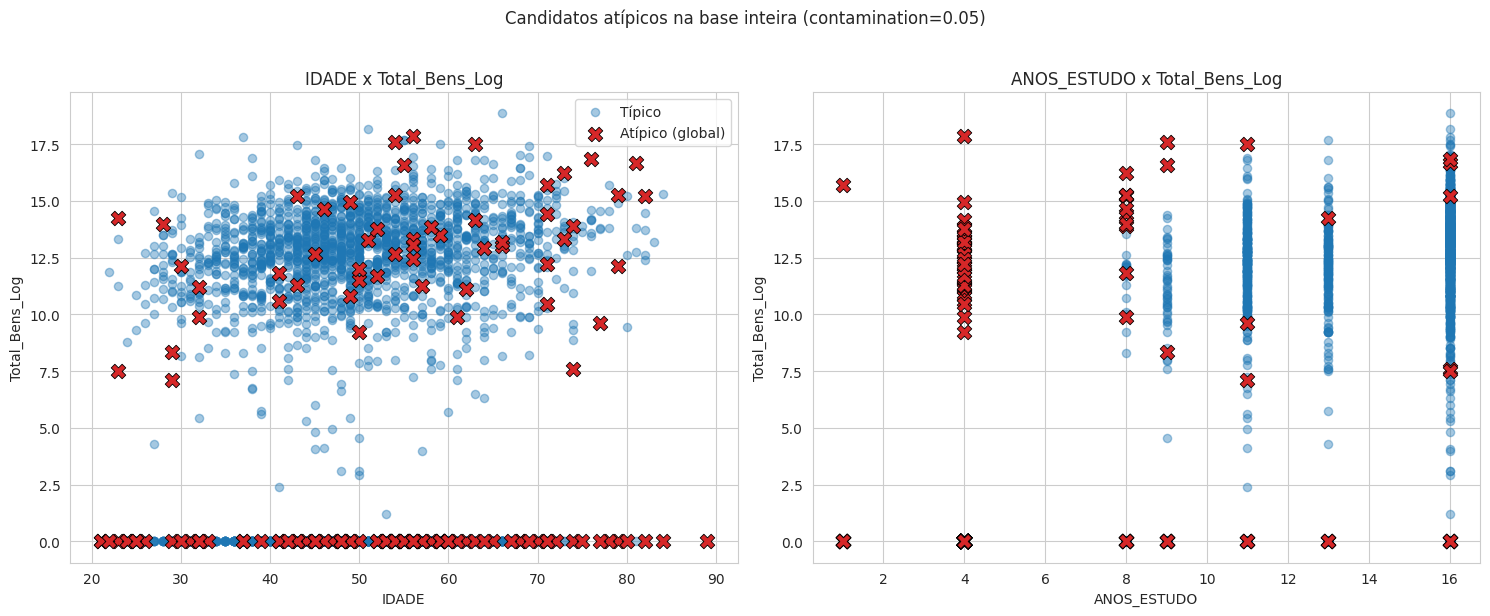

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

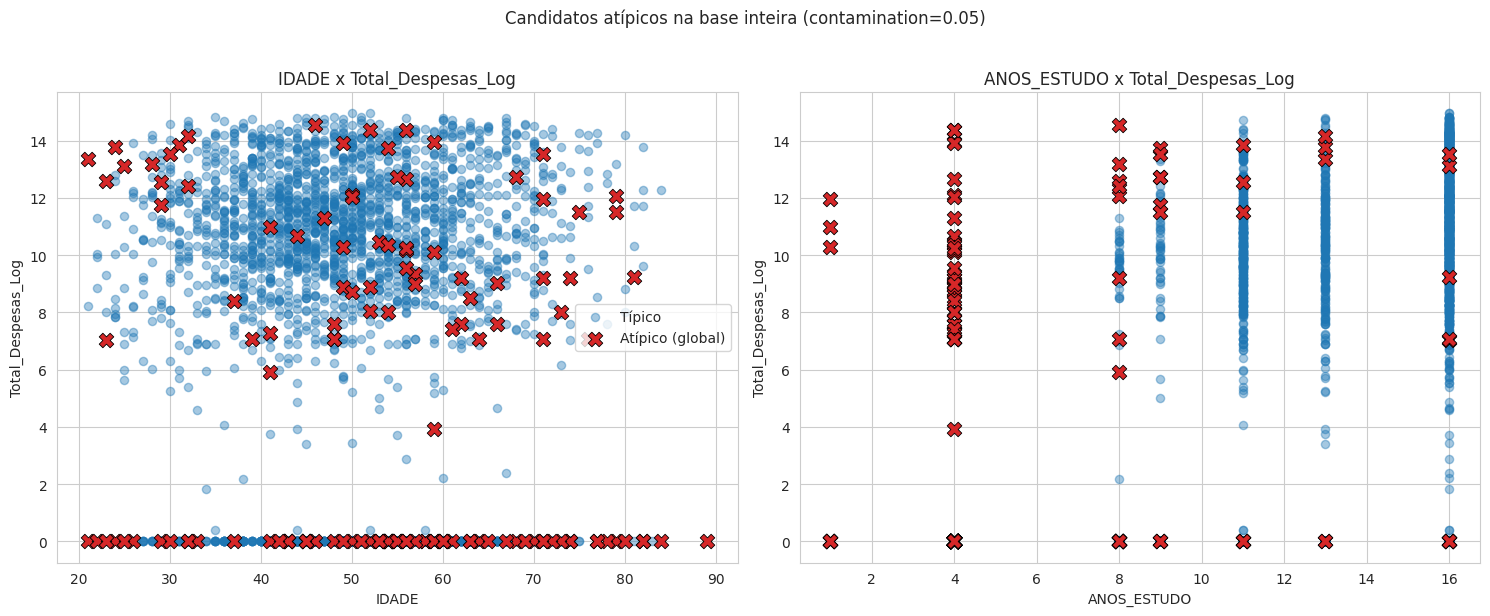

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (x_col, y_col) in zip(axes, [('IDADE', 'Total_Bens_Log'), ('ANOS_ESTUDO', 'Total_Bens_Log')]):
    tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
    atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']
    ax.scatter(tipicos[x_col], tipicos[y_col], c='tab:blue', alpha=0.4, s=35, label='Típico')
    ax.scatter(atipicos[x_col], atipicos[y_col], c='tab:red', marker='X', s=110,
               edgecolor='black', linewidth=0.6, label='Atípico (global)')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} x {y_col}')

axes[0].legend()
plt.suptitle(f'Candidatos atípicos na base inteira (contamination={contamination_global})', y=1.02)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (x_col, y_col) in zip(axes, [('IDADE', 'Total_Despesas_Log'), ('ANOS_ESTUDO', 'Total_Despesas_Log')]):
    tipicos = df_cluster[df_cluster['anomalia_global'] == 'Típico']
    atipicos = df_cluster[df_cluster['anomalia_global'] == 'Atípico']
    ax.scatter(tipicos[x_col], tipicos[y_col], c='tab:blue', alpha=0.4, s=35, label='Típico')
    ax.scatter(atipicos[x_col], atipicos[y_col], c='tab:red', marker='X', s=110,
               edgecolor='black', linewidth=0.6, label='Atípico (global)')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} x {y_col}')

axes[0].legend()
plt.suptitle(f'Candidatos atípicos na base inteira (contamination={contamination_global})', y=1.02)
plt.tight_layout()
plt.show()


### O mesmo recorte, em 3D

As duas variáveis de cada vez (painel acima) escondem alguma coisa: dois candidatos podem parecer próximos no plano `IDADE` x `Total_Bens_Log` e estar bem longe um do outro na terceira variável (`ANOS_ESTUDO`). Como o modelo usa as **4 variáveis-driver ao mesmo tempo**, um gráfico 3D interativo mostra isso escondendo uma dimensão — arrastem pra rotacionar, passem o mouse num ponto pra ver quem é. O primeiro gráfico mostra Total_bens_log e oculta Total_Despesa_log, e no segundo gráfico se invertem.


In [20]:
import plotly.graph_objects as go

cores_iso = {'Típico': '#1f77b4', 'Atípico': '#d62728'}

fig3d = go.Figure()
for status, cor in cores_iso.items():
    sub = df_cluster[df_cluster['anomalia_global'] == status]
    fig3d.add_trace(go.Scatter3d(
        x=sub['IDADE'], y=sub['ANOS_ESTUDO'], z=sub['Total_Bens_Log'],
        mode='markers', name=status,
        marker=dict(
            size=6 if status == 'Típico' else 9,
            color=cor,
            symbol='circle' if status == 'Típico' else 'diamond',
            opacity=0.5 if status == 'Típico' else 0.95,
            line=dict(width=1, color='black'),
        ),
        text=sub['NM_URNA_CANDIDATO'] + ' — ' + sub['cluster'],
        hovertemplate='<b>%{text}</b><br>IDADE=%{x}<br>ANOS_ESTUDO=%{y}<br>Total_Bens_Log=%{z:.2f}<extra></extra>',
    ))

fig3d.update_layout(
    scene=dict(xaxis_title='IDADE', yaxis_title='ANOS_ESTUDO', zaxis_title='Total_Bens_Log'),
    title=f'Candidatos atípicos (visão global) nas 3 das 4 variáveis-driver (contamination={contamination_global})',
    height=650, margin=dict(l=0, r=0, b=0, t=40),
)
fig3d.show()



A saída de streaming foi truncada nas últimas 5000 linhas.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utc

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [ ]:
cores_iso = {'Típico': '#1f77b4', 'Atípico': '#d62728'}

fig3d = go.Figure()
for status, cor in cores_iso.items():
    sub = df_cluster[df_cluster['anomalia_global'] == status]
    fig3d.add_trace(go.Scatter3d(
        x=sub['IDADE'], y=sub['ANOS_ESTUDO'], z=sub['Total_Despesas_Log'],
        mode='markers', name=status,
        marker=dict(
            size=6 if status == 'Típico' else 9,
            color=cor,
            symbol='circle' if status == 'Típico' else 'diamond',
            opacity=0.5 if status == 'Típico' else 0.95,
            line=dict(width=1, color='black'),
        ),
        text=sub['NM_URNA_CANDIDATO'] + ' — ' + sub['cluster'],
        hovertemplate='<b>%{text}</b><br>IDADE=%{x}<br>ANOS_ESTUDO=%{y}<br>Total_Bens_Log=%{z:.2f}<extra></extra>',
    ))

fig3d.update_layout(
    scene=dict(xaxis_title='IDADE', yaxis_title='ANOS_ESTUDO', zaxis_title='Total_Despesas_Log'),
    title=f'Candidatos atípicos (visão global) nas 3-4 variáveis-driver (contamination={contamination_global})',
    height=650, margin=dict(l=0, r=0, b=0, t=40),
)
fig3d.show()

---
## Detecção dentro de cada cluster: quem foge do padrão do próprio grupo?


In [21]:


resultados_cluster = []

for nome in df_cluster['cluster'].unique():
    sub_idx = df_cluster.index[df_cluster['cluster'] == nome].to_numpy()
    n = len(sub_idx)

    X_cluster = df_cluster.loc[sub_idx, colunas_driver].values
    X_cluster_padronizado = StandardScaler().fit_transform(X_cluster)

    contaminacao_cluster = min(max(0.05, 2 / n), 0.5)
    iso_cluster = IsolationForest(contamination=contaminacao_cluster, random_state=SEMENTE, n_estimators=200)
    pred_cluster = iso_cluster.fit_predict(X_cluster_padronizado)
    score_cluster = iso_cluster.decision_function(X_cluster_padronizado)

    n_atipicos = int((pred_cluster == -1).sum())
    print(f"{nome} (n={n}, contamination={contaminacao_cluster:.3f}): {n_atipicos} atípicos dentro do grupo")

    resultados_cluster.append(pd.DataFrame({
        'indice_original': sub_idx,
        'anomalia_cluster': np.where(pred_cluster == -1, 'Atípico', 'Típico'),
        'score_cluster': score_cluster,
    }))

anomalia_cluster_df = pd.concat(resultados_cluster).set_index('indice_original').sort_index()
df_cluster['anomalia_cluster'] = anomalia_cluster_df['anomalia_cluster'].values
df_cluster['score_cluster'] = anomalia_cluster_df['score_cluster'].values


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Acadêmicos de Baixo Orçamento (n=795, contamination=0.050): 40 atípicos dentro do grupo


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Financiados sem Patrimônio (n=515, contamination=0.050): 26 atípicos dentro do grupo


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Elite Financeira e Eleitoral (n=1127, contamination=0.050): 57 atípicos dentro do grupo


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Perfil Tradicional (n=363, contamination=0.050): 19 atípicos dentro do grupo


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [22]:
for nome in df_cluster['cluster'].unique():
    print(f"--- {nome}: mais atípicos dentro do grupo ---")
    sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == 'Atípico')]
    display(sub.sort_values('score_cluster')[colunas_ficha_anomalia + ['score_cluster']])


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

--- Acadêmicos de Baixo Orçamento: mais atípicos dentro do grupo ---


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Despesas,cluster,score_cluster
2015,GREGORY FRANÇA,PT,25,16,10967.14,400.00,Acadêmicos de Baixo Orçamento,-0.153772
9,SIDIMAR DO MERCADINHO,NOVO,41,8,135000.00,370.00,Acadêmicos de Baixo Orçamento,-0.140811
1462,IGOR OLIVEIRA,MISSÃO,30,13,75000.00,187.75,Acadêmicos de Baixo Orçamento,-0.130037
2769,MARCIO EMANECIO,DEMOCRATA,59,11,13000.00,1160.00,Acadêmicos de Baixo Orçamento,-0.118526
708,PASTOR JÚLIO CÉSAR,PSD,54,9,16000.00,288.00,Acadêmicos de Baixo Orçamento,-0.109527
2502,EDUARDO RIJO,PSDB,53,9,33000.00,150.00,Acadêmicos de Baixo Orçamento,-0.100217
780,DECINHO BOLSONARO DO BARREIRO,PODE,59,4,0.00,50.00,Acadêmicos de Baixo Orçamento,-0.100179
2590,ANDERSON GIMENES PAPAPENAL,AVANTE,41,13,0.00,41.02,Acadêmicos de Baixo Orçamento,-0.097034
660,VALDEMAR ABRAO,MISSÃO,55,11,30600.00,217.96,Acadêmicos de Baixo Orçamento,-0.090202
2596,RAMOS,AVANTE,44,13,32000.00,50.00,Acadêmicos de Baixo Orçamento,-0.089732


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

--- Perfil Tradicional: mais atípicos dentro do grupo ---


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Despesas,cluster,score_cluster
1284,CLEBIO LOPES JACARÉ,UNIÃO,56,4,57065162.25,1721235.48,Perfil Tradicional,-0.129352
1243,LOURIVAL GOMES,PSD,71,1,6608789.03,153876.00,Perfil Tradicional,-0.120200
604,VITAL HONORATO,AVANTE,79,8,4220000.00,173269.51,Perfil Tradicional,-0.059029
1573,RICARDO ABRÃO,PSDB,54,9,44497052.10,928896.23,Perfil Tradicional,-0.054950
1785,BAIANINHO DE MAUÁ,UNIÃO,52,4,949466.00,1714196.60,Perfil Tradicional,-0.048872
1610,JUNINHO DO PNEU,PSDB,49,4,3110108.15,1092338.50,Perfil Tradicional,-0.048432
1449,ZOINHO,REPUBLICANOS,73,4,608700.04,3000.00,Perfil Tradicional,-0.045455
2419,COMENDADOR BRILHANTE,PDT,71,4,35000.00,10055.78,Perfil Tradicional,-0.045049
490,EMIDINHO MADEIRA,PL,59,4,714357.99,1144544.60,Perfil Tradicional,-0.036210
247,LUISINHO CORREDOR,PT,66,4,450000.00,2000.00,Perfil Tradicional,-0.031699


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

### O mesmo recorte, em 3D — filtrando por cluster

Mesma ideia do gráfico 3D global, agora um por cluster: escolham no menu qual grupo olhar (cada cluster usa a sua **própria** padronização, então os pontos vermelhos aqui são atípicos *dentro daquele grupo*, não em relação à base inteira). Os eixos ficam fixos entre um cluster e outro, pra dar pra comparar a posição relativa. 1º Considerando Total de Bens 2º Despesas


In [23]:
nomes_bisecting_ordenados = list(df_cluster['cluster'].unique())
n_status = len(cores_iso)  # 'Típico' e 'Atípico', mesmas cores do gráfico 3D global

fig3d_cluster = go.Figure()
for idx_cluster, nome in enumerate(nomes_bisecting_ordenados):
    for status, cor in cores_iso.items():
        sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == status)]
        fig3d_cluster.add_trace(go.Scatter3d(
            x=sub['IDADE'], y=sub['ANOS_ESTUDO'], z=sub['Total_Bens_Log'],
            mode='markers', name=status,
            marker=dict(
                size=6 if status == 'Típico' else 9,
                color=cor,
                symbol='circle' if status == 'Típico' else 'diamond',
                opacity=0.55 if status == 'Típico' else 0.95,
                line=dict(width=1, color='black'),
            ),
            text=sub['NM_URNA_CANDIDATO'],
            hovertemplate='<b>%{text}</b><br>IDADE=%{x}<br>ANOS_ESTUDO=%{y}<br>Total_Bens_Log=%{z:.2f}<extra></extra>',
            visible=(idx_cluster == 0),       # só o primeiro cluster começa visível
            legendgroup=status,
            showlegend=(idx_cluster == 0),    # legenda não se repete a cada cluster
        ))

# um botão por cluster no menu suspenso — cada um liga só os 2 traços (Típico/Atípico) daquele cluster
botoes_cluster = []
for idx_cluster, nome in enumerate(nomes_bisecting_ordenados):
    visibilidade = [False] * (len(nomes_bisecting_ordenados) * n_status)
    for j in range(n_status):
        visibilidade[idx_cluster * n_status + j] = True
    botoes_cluster.append(dict(
        label=nome, method='update',
        args=[{'visible': visibilidade}, {'title': f'Atípicos dentro do cluster: {nome}'}],
    ))

fig3d_cluster.update_layout(
    scene=dict(
        xaxis_title='IDADE', yaxis_title='ANOS_ESTUDO', zaxis_title='Total_Bens_Log',
        xaxis=dict(range=[df_cluster['IDADE'].min() - 2, df_cluster['IDADE'].max() + 2]),
        yaxis=dict(range=[df_cluster['ANOS_ESTUDO'].min() - 1, df_cluster['ANOS_ESTUDO'].max() + 1]),
        zaxis=dict(range=[df_cluster['Total_Bens_Log'].min() - 0.5, df_cluster['Total_Bens_Log'].max() + 0.5]),
    ),
    updatemenus=[dict(active=0, buttons=botoes_cluster, x=0.02, y=1.05, xanchor='left')],
    title=f'Atípicos dentro do cluster: {nomes_bisecting_ordenados[0]}',
    height=650, margin=dict(l=0, r=0, b=0, t=60),
)
fig3d_cluster.show()


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [24]:
nomes_bisecting_ordenados = list(df_cluster['cluster'].unique())
n_status = len(cores_iso)  # 'Típico' e 'Atípico', mesmas cores do gráfico 3D global

fig3d_cluster = go.Figure()
for idx_cluster, nome in enumerate(nomes_bisecting_ordenados):
    for status, cor in cores_iso.items():
        sub = df_cluster[(df_cluster['cluster'] == nome) & (df_cluster['anomalia_cluster'] == status)]
        fig3d_cluster.add_trace(go.Scatter3d(
            x=sub['IDADE'], y=sub['ANOS_ESTUDO'], z=sub['Total_Despesas_Log'],
            mode='markers', name=status,
            marker=dict(
                size=6 if status == 'Típico' else 9,
                color=cor,
                symbol='circle' if status == 'Típico' else 'diamond',
                opacity=0.55 if status == 'Típico' else 0.95,
                line=dict(width=1, color='black'),
            ),
            text=sub['NM_URNA_CANDIDATO'],
            hovertemplate='<b>%{text}</b><br>IDADE=%{x}<br>ANOS_ESTUDO=%{y}<br>Total_Despesas_Log=%{z:.2f}<extra></extra>',
            visible=(idx_cluster == 0),       # só o primeiro cluster começa visível
            legendgroup=status,
            showlegend=(idx_cluster == 0),    # legenda não se repete a cada cluster
        ))

# um botão por cluster no menu suspenso — cada um liga só os 2 traços (Típico/Atípico) daquele cluster
botoes_cluster = []
for idx_cluster, nome in enumerate(nomes_bisecting_ordenados):
    visibilidade = [False] * (len(nomes_bisecting_ordenados) * n_status)
    for j in range(n_status):
        visibilidade[idx_cluster * n_status + j] = True
    botoes_cluster.append(dict(
        label=nome, method='update',
        args=[{'visible': visibilidade}, {'title': f'Atípicos dentro do cluster: {nome}'}],
    ))

fig3d_cluster.update_layout(
    scene=dict(
        xaxis_title='IDADE', yaxis_title='ANOS_ESTUDO', zaxis_title='Total_Bens_Log',
        xaxis=dict(range=[df_cluster['IDADE'].min() - 2, df_cluster['IDADE'].max() + 2]),
        yaxis=dict(range=[df_cluster['ANOS_ESTUDO'].min() - 1, df_cluster['ANOS_ESTUDO'].max() + 1]),
        zaxis=dict(range=[df_cluster['Total_Bens_Log'].min() - 0.5, df_cluster['Total_Despesas_Log'].max() + 0.5]),
    ),
    updatemenus=[dict(active=0, buttons=botoes_cluster, x=0.02, y=1.05, xanchor='left')],
    title=f'Atípicos dentro do cluster: {nomes_bisecting_ordenados[0]}',
    height=650, margin=dict(l=0, r=0, b=0, t=60),
)
fig3d_cluster.show()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

### Comparando: global vs. dentro do cluster

Quatro combinações possíveis pra cada candidato: atípico nos dois recortes (destoa de tudo, robusto), só globalmente, só dentro do cluster, ou típico nos dois. O caso mais interessante pedagogicamente é o **"só dentro do cluster"**: candidatos que passam despercebidos quando olhamos a base inteira, mas que não se parecem com seus próprios colegas de grupo.


In [25]:
tabela_comparacao = pd.crosstab(df_cluster['anomalia_global'], df_cluster['anomalia_cluster'])
tabela_comparacao.index.name = 'anomalia_global \\ anomalia_cluster'
display(tabela_comparacao)

so_no_cluster = df_cluster[(df_cluster['anomalia_global'] == 'Típico') & (df_cluster['anomalia_cluster'] == 'Atípico')]
print(f"\n{len(so_no_cluster)} candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):")
so_no_cluster[colunas_ficha_anomalia + ['score_cluster']].sort_values('score_cluster')


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

anomalia_cluster,Atípico,Típico
anomalia_global \ anomalia_cluster,,
Atípico,59,81
Típico,83,2577


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v


83 candidatos são atípicos só DENTRO do próprio cluster (passariam despercebidos na análise global):


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,NM_URNA_CANDIDATO,SG_PARTIDO,IDADE,ANOS_ESTUDO,Total_Bens,Total_Despesas,cluster,score_cluster
1173,LUCIANO GUERREIRO,MDB,55,13,47295510.76,75362.66,Elite Financeira e Eleitoral,-0.164128
918,ROBERTO MONTEIRO-PAI,PL,69,13,250000.00,2106632.10,Elite Financeira e Eleitoral,-0.157976
2015,GREGORY FRANÇA,PT,25,16,10967.14,400.00,Acadêmicos de Baixo Orçamento,-0.153772
484,FABINHO RAMALHO,PL,64,13,20023780.20,472392.68,Elite Financeira e Eleitoral,-0.151896
93,IRINY,PT,70,13,180000.00,1071164.88,Elite Financeira e Eleitoral,-0.148072
...,...,...,...,...,...,...,...,...
1806,ANADETHY,MDB,62,16,32000.00,849.38,Elite Financeira e Eleitoral,-0.001605
661,CARLOS HENRIQUE DIAS,MISSÃO,24,13,6494.60,4671.78,Perfil Tradicional,-0.001530
281,DARIO FERREIRA,REPUBLICANOS,68,16,24075000.00,12000.00,Elite Financeira e Eleitoral,-0.000871
1246,MARIA ANGELICA,PSD,70,13,1200000.00,1400.00,Perfil Tradicional,-0.000825


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

---
## Fechamento

Com esta Fase 4, fecha-se o pipeline completo: preparação de dados (Fase 0), análise descritiva (Fase 1), clusterização — K-Means, Bisecting K-Means, DBSCAN e hierárquico (Fase 2), regras de associação (Fase 3) e, agora, detecção de anomalias, tanto na base inteira quanto dentro de cada cluster nomeado na Fase